In [25]:
import sys
print(sys.version)

3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]


In [26]:
import numpy as np 
import pandas as pd 
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
#from supabase import create_client, Client 


In [27]:
# initialize supabase client 

# url: str = os.environ.get("https://mhmtfreaktsvcatukudi.supabase.co")
# key: str = os.environ.get("sb_publishable_xko_wd2pmQ58EwLh3ARE1g_Mfyx6_6K")
# supabase: Client = create_client(url, key)

In [28]:
# Define file path
# Read in .csv students file

f_path = Path.cwd().joinpath('mock_data', 'bangladesh_student_performance.csv')
print(f_path)

with open(f_path, 'r') as f:
    students_df = pd.read_csv(f)
    print(students_df.head())

c:\Users\steph\Documents\GitHub\Smokey_pipeline_mazes\mock_data\bangladesh_student_performance.csv
   Student_ID  Gender  Age    District School_Type  Study_Hours_per_Week  \
0           1    Male   16     Rangpur     Private                    11   
1           2  Female   17    Rajshahi     Private                     7   
2           3    Male   15     Barisal     Private                    27   
3           4    Male   15  Mymensingh     Private                    18   
4           5    Male   15  Mymensingh      Public                    28   

   Attendance  Parent_Education  Family_Income_BDT Internet_Access  \
0          70          Graduate              49169             Yes   
1          76           Primary              57947              No   
2          63  Higher Secondary              57224             Yes   
3          84           Primary              55865              No   
4          89  Higher Secondary              35553              No   

  Private_Tuition  Prev

In [29]:
#print(students_df.describe())

In [30]:
print(students_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student_ID            1000 non-null   int64  
 1   Gender                1000 non-null   str    
 2   Age                   1000 non-null   int64  
 3   District              1000 non-null   str    
 4   School_Type           1000 non-null   str    
 5   Study_Hours_per_Week  1000 non-null   int64  
 6   Attendance            1000 non-null   int64  
 7   Parent_Education      1000 non-null   str    
 8   Family_Income_BDT     1000 non-null   int64  
 9   Internet_Access       1000 non-null   str    
 10  Private_Tuition       1000 non-null   str    
 11  Previous_GPA          1000 non-null   float64
 12  SSC_Result            1000 non-null   float64
 13  HSC_Result            1000 non-null   float64
dtypes: float64(3), int64(5), str(6)
memory usage: 109.5 KB
None


In [31]:
# Convert all string columns to categorical codes for modeling
category_mappings = {}

for col in students_df.columns:
    if pd.api.types.is_string_dtype(students_df[col]):
        cat_series = students_df[col].astype('category')
        
        # store mapping
        category_mappings[col] = dict(enumerate(cat_series.cat.categories))
        
        # replace with codes
        students_df[col] = cat_series.cat.codes

In [32]:
print(students_df.head())
#print(students_df.info())

   Student_ID  Gender  Age  District  School_Type  Study_Hours_per_Week  \
0           1       1   16         6            0                    11   
1           2       0   17         5            0                     7   
2           3       1   15         0            0                    27   
3           4       1   15         4            0                    18   
4           5       1   15         4            1                    28   

   Attendance  Parent_Education  Family_Income_BDT  Internet_Access  \
0          70                 0              49169                1   
1          76                 2              57947                0   
2          63                 1              57224                1   
3          84                 2              55865                0   
4          89                 1              35553                0   

   Private_Tuition  Previous_GPA  SSC_Result  HSC_Result  
0                1          4.83        4.22        5.00  
1   

In [33]:
category_mappings['Gender']

{0: 'Female', 1: 'Male'}

In [34]:
students_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student_ID            1000 non-null   int64  
 1   Gender                1000 non-null   int8   
 2   Age                   1000 non-null   int64  
 3   District              1000 non-null   int8   
 4   School_Type           1000 non-null   int8   
 5   Study_Hours_per_Week  1000 non-null   int64  
 6   Attendance            1000 non-null   int64  
 7   Parent_Education      1000 non-null   int8   
 8   Family_Income_BDT     1000 non-null   int64  
 9   Internet_Access       1000 non-null   int8   
 10  Private_Tuition       1000 non-null   int8   
 11  Previous_GPA          1000 non-null   float64
 12  SSC_Result            1000 non-null   float64
 13  HSC_Result            1000 non-null   float64
dtypes: float64(3), int64(5), int8(6)
memory usage: 68.5 KB


#### Target Variable for Analysis will be Higher Secondary Certificate Results (HSC score)

In [35]:
# Need to convert HSC_Result to Category Labels based on GPA thresholds:
# Final_Result_Class (Higher Secondary Certificate Results)
# GPA ≥ 4.5 → "Excellent"
# 4.0–4.49 → "Good"
# 3.0–3.99 → "Average"
# < 3.0 → "Poor"

col         = 'HSC_Result'
conditions  = [students_df[col] >= 4.5, (students_df[col] >= 4.0) & (students_df[col] < 4.5), (students_df[col] >= 3.0) & (students_df[col] < 4.0), students_df[col] < 3.0]
choices     = ["Excellent", "Good", "Average", "Poor"]
    
students_df["Grade_Class"] = np.select(conditions, choices, default="Unknown")
#print(students_df.head())
print(students_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student_ID            1000 non-null   int64  
 1   Gender                1000 non-null   int8   
 2   Age                   1000 non-null   int64  
 3   District              1000 non-null   int8   
 4   School_Type           1000 non-null   int8   
 5   Study_Hours_per_Week  1000 non-null   int64  
 6   Attendance            1000 non-null   int64  
 7   Parent_Education      1000 non-null   int8   
 8   Family_Income_BDT     1000 non-null   int64  
 9   Internet_Access       1000 non-null   int8   
 10  Private_Tuition       1000 non-null   int8   
 11  Previous_GPA          1000 non-null   float64
 12  SSC_Result            1000 non-null   float64
 13  HSC_Result            1000 non-null   float64
 14  Grade_Class           1000 non-null   str    
dtypes: float64(3), int64(5), int8(6),

In [ ]:
# Convert Grade_Class to categorical codes for modeling (can use ordinalencoder for target variable)



In [36]:
# Check for multicollinearity

corr_matrix = students_df.corr()

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Multicollinearity Heat Map')

ValueError: could not convert string to float: 'Excellent'

<Axes: >

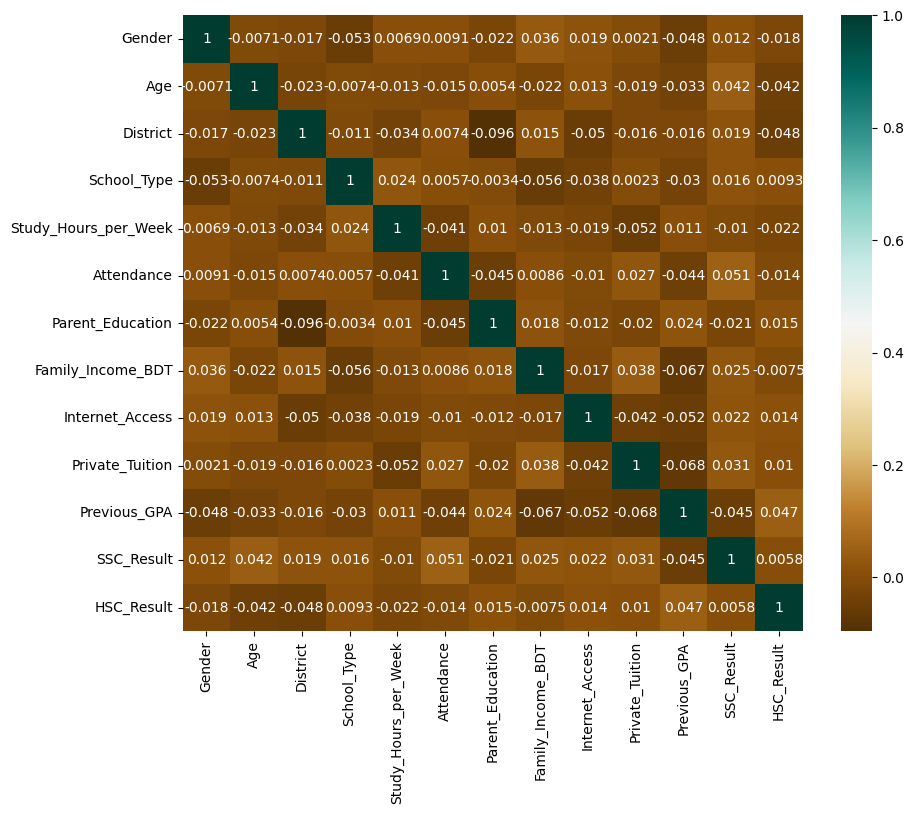

In [ ]:
plt.figure(figsize = (10,8))
sns.heatmap(students_df.corr(),annot = True, cmap = 'BrBG')

In [ ]:
# Drop student_id column as it is not useful for modeling
students_df.drop('Student_ID', axis=1, inplace=True)
# Also drop 'HSC_Result' as it overlaps with new target variable derived from it, 'Grade_Class'
students_df.drop('HSC_Result', axis=1, inplace=True)
print(students_df.head())

   Gender  Age  District  School_Type  Study_Hours_per_Week  Attendance  \
0       1   16         6            0                    11          70   
1       0   17         5            0                     7          76   
2       1   15         0            0                    27          63   
3       1   15         4            0                    18          84   
4       1   15         4            1                    28          89   

   Parent_Education  Family_Income_BDT  Internet_Access  Private_Tuition  \
0                 0              49169                1                1   
1                 2              57947                0                0   
2                 1              57224                1                1   
3                 2              55865                0                0   
4                 1              35553                0                1   

   Previous_GPA  SSC_Result  HSC_Result  
0          4.83        4.22        5.00  
1       

### Split Dataset

In [ ]:
# Split the data into training and testing sets:
# Separate into Features (X) and Target (Y)
# GOAL: Predict whether a student has good performance (grade >= 7) or not (grade < 7)

X = students_df.drop(columns=["HSC_Result"])
#y = np.select([students_df["HSC_Result"] )  # 1 for good quality, 0 for bad quality
print("Features shape:", X.shape)
print("Target shape:", y.shape)


## Normality, outlier assumptions checks, scaling

In [ ]:
# Viz check for outliers:

